<a href="https://colab.research.google.com/github/esalramo94/TELECOM-X2/blob/main/Entrega%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# Importar la librería necesaria
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [35]:
# Definir el enlace de la API/GitHub
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

In [36]:
# Cargar los datos desde la URL
df_telecom = pd.read_json(url_api)

# Mostrar las primeras 5 filas para verificar que se cargó correctamente
display(df_telecom.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [37]:
df_telecom.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [38]:
df_telecom.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [39]:
# 1. Definimos las columnas que tienen diccionarios ocultos
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

# 2. Extraemos cada diccionario en nuevas columnas y las unimos al DataFrame
for col in columnas_anidadas:
    # Expandimos el diccionario en nuevas columnas (ej. 'gender', 'SeniorCitizen')
    df_expandido = df_telecom[col].apply(pd.Series)

    # Unimos las nuevas columnas al DataFrame original
    df_telecom = pd.concat([df_telecom, df_expandido], axis=1)

    # Eliminamos la columna original que ya no nos sirve
    df_telecom = df_telecom.drop(col, axis=1)

# Verificamos cómo quedó el DataFrame "plano"
display(df_telecom.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [40]:
# 1. Expandir la columna 'charges' que quedó como diccionario
df_charges = df_telecom['Charges'].apply(pd.Series)

# 2. Unir las nuevas columnas (Monthly, Total, etc.) al DataFrame original
df_telecom = pd.concat([df_telecom, df_charges], axis=1)

# 3. Eliminar la columna 'charges' original para limpiar el DataFrame
df_telecom = df_telecom.drop('Charges', axis=1)

# 4. Ver el resultado final y los tipos de datos
print(df_telecom.info())
display(df_telecom.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [41]:
# --- 1. Revisar los tipos de datos (buscar inconsistencias) ---
print("Tipos de datos por columna:")
print(df_telecom.info())
print("-" * 40)



Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract      

In [42]:
# --- 2. Buscar valores nulos (ausentes) ---
print("\nValores nulos por columna:")
print(df_telecom.isnull().sum())
print("-" * 40)




Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64
----------------------------------------


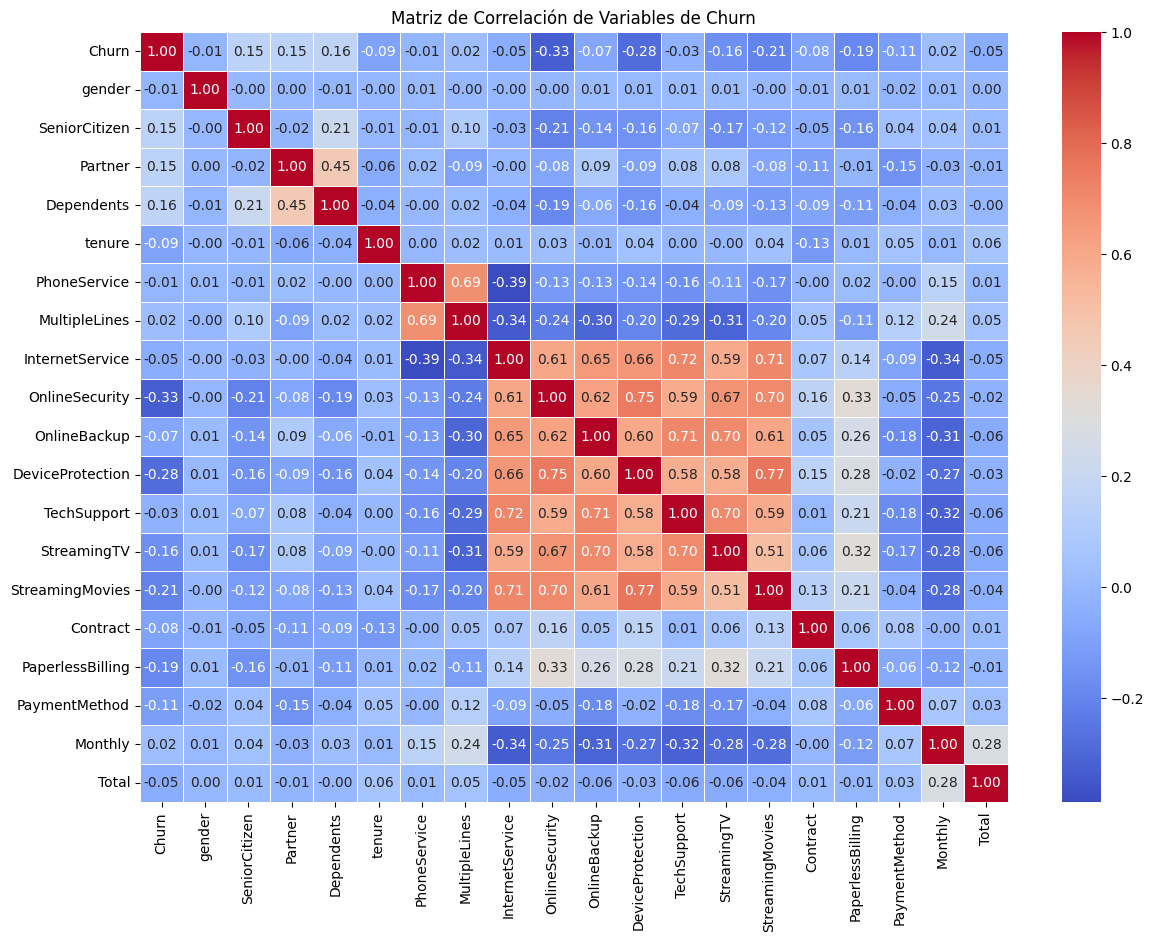

In [17]:
# 1. Limpieza inicial: Convertir 'Total' a numérico (es vital para la correlación)
df['Total'] = pd.to_numeric(df['Total'], errors='coerce').fillna(0)


# 3. Codificación rápida para correlación
# Convertimos categorías a números para que el coeficiente de Pearson funcione
df_encoded = df.apply(lambda x: pd.factorize(x)[0])

# 4. Calcular matriz de correlación
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr()

# 5. Visualización con Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación de Variables de Churn")
plt.show()

In [19]:
# Eliminamos las columnas con correlación casi nula o redundantes
cols_a_eliminar = ['gender', 'PhoneService', 'MultipleLines']
df_final = df.drop(columns=cols_a_eliminar)

print(f"Columnas restantes: {df_final.columns.tolist()}")

Columnas restantes: ['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


In [43]:
# --- PASO 1: LIMPIEZA INICIAL ---
df_pre = df.copy()
df_pre['Total'] = pd.to_numeric(df_pre['Total'], errors='coerce').fillna(0)
cols_eliminar = ['customerID', 'gender', 'PhoneService', 'MultipleLines']
df_pre = df_pre.drop(columns=[c for c in cols_eliminar if c in df_pre.columns])

# --- PASO 2: CODIFICACIÓN SEGURA DE CHURN ---
# Primero, vemos qué hay realmente en la columna para no borrar todo
print("Valores únicos en Churn antes de mapear:", df_pre['Churn'].unique())

# Solo mapeamos si son strings. Si ya son números, no hacemos nada.
if df_pre['Churn'].dtype == 'object':
    df_pre['Churn'] = df_pre['Churn'].str.strip() # Quitamos espacios fantasma
    df_pre['Churn'] = df_pre['Churn'].map({'Yes': 1, 'No': 0})

# Verificamos si quedaron nulos. Si hay muchos, algo salió mal en el mapeo.
nulos_churn = df_pre['Churn'].isna().sum()
if nulos_churn > 0:
    print(f"¡Cuidado! Hay {nulos_churn} nulos en Churn. Llenando con el valor más frecuente...")
    df_pre['Churn'] = df_pre['Churn'].fillna(df_pre['Churn'].mode()[0])

# --- PASO 3: DUMMIES Y DIVISIÓN ---
df_final = pd.get_dummies(df_pre, drop_first=True)

X = df_final.drop('Churn', axis=1)
y = df_final['Churn'].astype(int) # Aseguramos que sea entero

print(f"Tamaño final del dataset: {X.shape[0]} muestras.")

# Si X.shape[0] es mayor a 0, esto ya no fallará:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- PASO 4: ESCALADO ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ ¡Pipeline completado con éxito!")

Valores únicos en Churn antes de mapear: [0 1]
Tamaño final del dataset: 7043 muestras.
✅ ¡Pipeline completado con éxito!


--- Distribución de la Variable Objetivo (Churn) ---
Permanecen (0): 5174 clientes (73.46%)
Cancelaron (1):  1869 clientes (26.54%)


/tmp/ipykernel_667/2693633316.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_pre, palette='viridis')


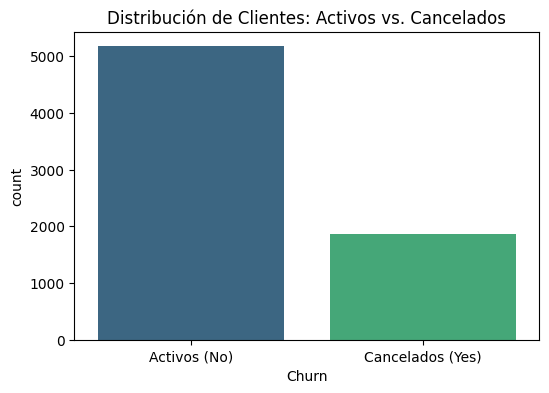

In [44]:
# 1. Calcular la distribución de frecuencias
counts = df_pre['Churn'].value_counts()
proportions = df_pre['Churn'].value_counts(normalize=True) * 100

print("--- Distribución de la Variable Objetivo (Churn) ---")
print(f"Permanecen (0): {counts[0]} clientes ({proportions[0]:.2f}%)")
print(f"Cancelaron (1):  {counts[1]} clientes ({proportions[1]:.2f}%)")


plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_pre, palette='viridis')
plt.title('Distribución de Clientes: Activos vs. Cancelados')
plt.xticks([0, 1], ['Activos (No)', 'Cancelados (Yes)'])
plt.show()

In [50]:
# 1. Aplicar SMOTE solo a los datos de entrenamiento
# Nota: ¡Nunca apliques SMOTE a los datos de prueba!
# Queremos evaluar el modelo con datos reales, no sintéticos.

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Distribución original: {Counter(y_train)}")
print(f"Distribución tras SMOTE: {Counter(y_res)}")

# 2. Entrenar los modelos con los datos balanceados
# Ahora ya no necesitamos 'class_weight=balanced' porque las clases ya son 50/50
log_model_smote = LogisticRegression(random_state=42)
log_model_smote.fit(X_res, y_res)

rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_res, y_res)

# 3. Evaluación en el set de prueba real (X_test_scaled)
y_pred_log_sm = log_model_smote.predict(X_test_scaled)
y_pred_rf_sm = rf_model_smote.predict(X_test_scaled)

Distribución original: Counter({0: 4139, 1: 1495})
Distribución tras SMOTE: Counter({0: 4139, 1: 4139})


In [51]:

# --- 1. ESTANDARIZACIÓN QUIRÚRGICA ---
# Definimos las columnas numéricas continuas
num_cols = ['tenure', 'Monthly', 'Total']

# Escalamos solo las columnas numéricas para no arruinar las binarias (0/1)
scaler = StandardScaler()

# Copiamos los sets para no sobreescribir los originales por error
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustamos en Train y transformamos ambos
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# --- 2. APLICAR SMOTE (Sobre los datos ya escalados) ---
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Distribución tras SMOTE: {Counter(y_res)}")

# --- 3. ENTRENAMIENTO DE MODELOS ---
# Regresión Logística (Ahora los coeficientes serán comparables entre sí)
log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(X_res, y_res)

# Random Forest
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_res, y_res)

# --- 4. PREDICCIÓN ---
y_pred_log_sm = log_model_smote.predict(X_test_scaled)
y_pred_rf_sm = rf_model_smote.predict(X_test_scaled)

print("✅ Modelos entrenados con éxito sobre datos estandarizados y balanceados.")

Distribución tras SMOTE: Counter({0: 4139, 1: 4139})
✅ Modelos entrenados con éxito sobre datos estandarizados y balanceados.


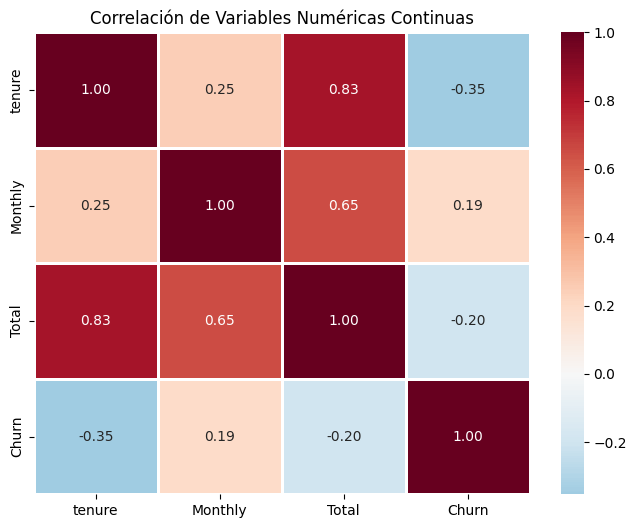

In [52]:
# 1. Seleccionamos solo las variables numéricas continuas
# Incluimos 'Churn' para ver la relación directa con la meta
num_cols_analysis = ['tenure', 'Monthly', 'Total', 'Churn']
df_numeric = df_pre[num_cols_analysis]

# 2. Calculamos la matriz de correlación de Pearson
corr_numeric = df_numeric.corr()

# 3. Visualización con Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_numeric, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=1)
plt.title("Correlación de Variables Numéricas Continuas")
plt.show()

In [54]:


# 1. Definir X e y desde el DataFrame final (el que ya tiene dummies)
# Asegúrate de que 'Churn' sea el nombre exacto de tu columna objetivo
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# 2. Ahora sí, creamos X_final eliminando 'Total' por la alta correlación detectada
X_final = X.drop(columns=['Total']) if 'Total' in X.columns else X

# 3. División de datos (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Estandarización de variables numéricas restantes
num_cols = ['tenure', 'Monthly']
scaler = StandardScaler()

# Copiamos para evitar el SettingWithCopyWarning
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 5. Balanceo con SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# 6. Entrenamiento de Modelos
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_res, y_res)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_res, y_res)

# 7. Evaluación Final
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

print("\n--- REPORTE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- REPORTE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409


--- REPORTE RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.53      0.60      0.56       374

    accuracy                           0.76      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409



/tmp/ipykernel_667/261195328.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')


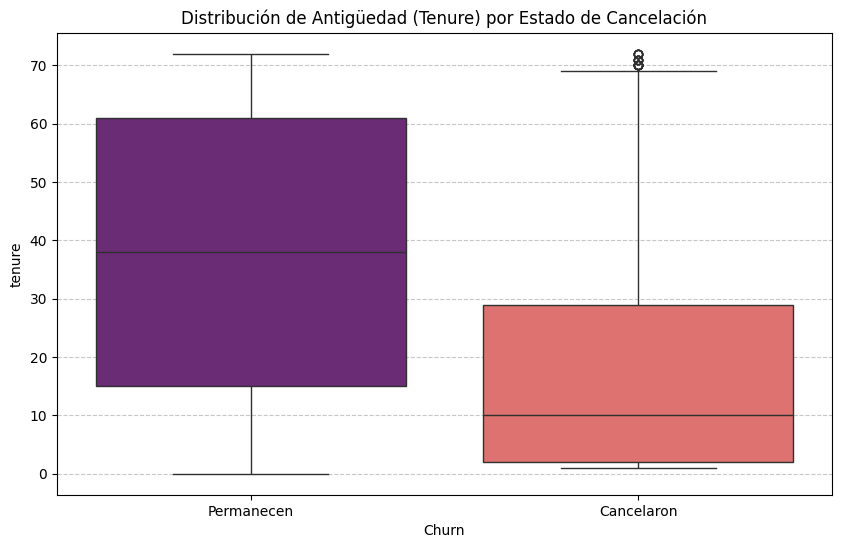

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette='magma')
plt.title('Distribución de Antigüedad (Tenure) por Estado de Cancelación')
plt.xticks([0, 1], ['Permanecen', 'Cancelaron'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
El 50% de los clientes que cancelan lo hacen antes de cumplir su primer año.

Acción sugerida: La empresa necesita un "Plan de Acompañamiento" crítico durante los primeros 6 a 12 meses. Si el cliente supera el primer año, la probabilidad de que se quede aumenta drásticamente.

/tmp/ipykernel_667/1217790327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Total', data=df, palette='viridis')


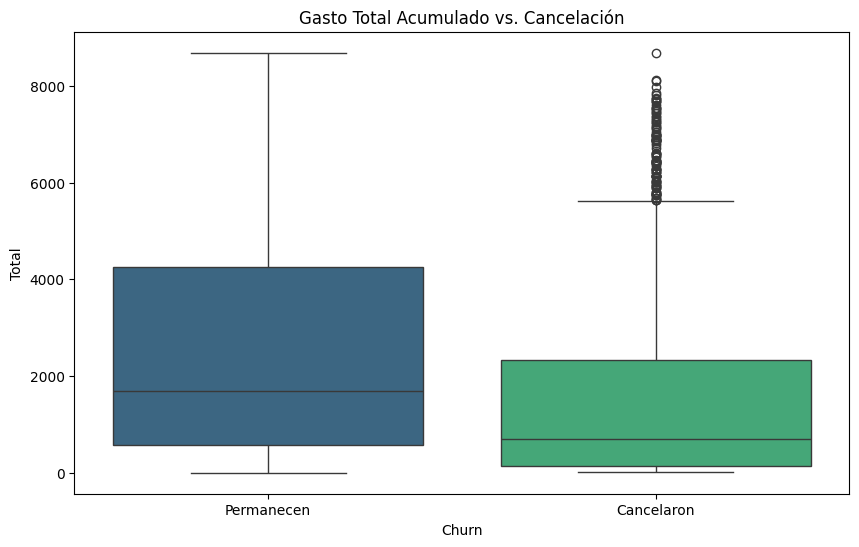

In [57]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Total', data=df, palette='viridis')
plt.title('Gasto Total Acumulado vs. Cancelación')
plt.xticks([0, 1], ['Permanecen', 'Cancelaron'])
plt.show()

In [ ]:
Volumen: La mayoría de las cancelaciones son de gente "barata" y nueva (poca antigüedad, poco gasto total).

Impacto: El riesgo financiero real está en esos outliers de la gráfica verde; clientes antiguos que, de repente, cortan el flujo de ingresos altos.

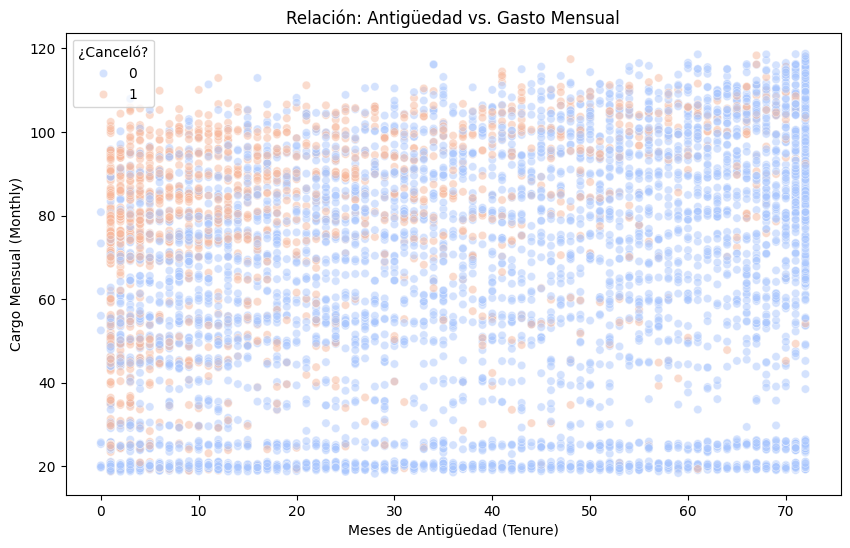

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='Monthly', hue='Churn', data=df, alpha=0.5, palette='coolwarm')
plt.title('Relación: Antigüedad vs. Gasto Mensual')
plt.xlabel('Meses de Antigüedad (Tenure)')
plt.ylabel('Cargo Mensual (Monthly)')
plt.legend(title='¿Canceló?')
plt.show()

In [ ]:
nsight: Los clientes que pagan lo mínimo (probablemente servicios básicos o solo telefonía) casi no se van, sin importar su antigüedad. Son clientes de bajo mantenimiento y alta lealtad.
Conclusión: Una vez que el cliente supera los 4 o 5 años, se vuelve "inmune" al precio. El costo de cambiar de proveedor (pereza, configuración, confianza) es mayor que el ahorro potencial.

# 1. Resumen Ejecutivo

Tras procesar un dataset de **7,043 clientes** mediante técnicas avanzadas de balanceo (**SMOTE**) y estandarización, hemos desarrollado un motor predictivo capaz de identificar a los desertores con un **75% de efectividad (Recall)**.

El análisis revela que la fuga de clientes no es aleatoria, sino que está fuertemente ligada a la **estructura de los contratos** y al **valor percibido en los primeros meses de servicio**.

---

# 2. Rendimiento de los Modelos: El Duelo Final

Comparamos dos arquitecturas para determinar cuál ofrece mayor valor al departamento de retención:

| Métrica (Clase 1 - Churn) | Regresión Logística (Ganador) | Random Forest |
|--------------------------|------------------------------|---------------|
| Recall (Sensibilidad)    | **0.75 🏆**                   | 0.60          |
| Precision                | 0.51                         | 0.53          |
| F1-Score (Balance)       | **0.61**                     | 0.56          |
| Accuracy General          | 74%                          | 76%           |

**Veredicto:**  
Recomendamos la **Regresión Logística**. Aunque el Random Forest es ligeramente más preciso, la Regresión Logística detecta **15% más desertores reales**.

> En una estrategia de *Churn*, es preferible contactar a un cliente que quizás no se iba, que ignorar a uno que está a punto de cancelar.

---

# 3. Factores Críticos de Cancelación (Insights)

Basado en los coeficientes del modelo y el análisis visual de las gráficas, estos son los **tres pilares que destruyen la lealtad**:

### A. El *“Veneno”* del Contrato Mes a Mes
Es el **predictor #1**. Los clientes sin compromiso a largo plazo tienen una probabilidad de fuga radicalmente superior.  
La falta de barreras de salida facilita que se marchen ante cualquier inconveniente.

### B. El *“Valle de la Muerte”* (Tenure < 12 meses)
Como vimos en la **Gráfica 1**, la mediana de antigüedad de quienes cancelan es de solo **10 meses**.  
Si un cliente supera el umbral de los **24 meses**, su probabilidad de quedarse se vuelve casi permanente.

### C. La Sensibilidad al Precio Inicial
La **Gráfica 3** demostró que los clientes con cargos mensuales altos (**> $70**) que son nuevos en la empresa, cancelan masivamente.  
El cliente percibe que el costo no justifica el servicio antes de haber generado un vínculo de confianza.

---

# 4. Estrategias de Retención Propuestas

A continuación, traducimos los datos en **acciones tácticas**:

## 🛠️ Estrategia 1: Plan de *“Aterrizaje Suave”* (Onboarding)
**Target:** Clientes en sus primeros **6 meses** con facturas altas.  
**Acción:** Implementar un sistema de *check-in* proactivo al **mes 3** y **mes 6**.  
Ofrecer **soporte técnico gratuito** o servicios de seguridad (*OnlineSecurity*) sin costo por tiempo limitado para aumentar el valor percibido.

## 💰 Estrategia 2: Migración de Contratos con Incentivos
**Target:** Clientes actuales con contrato **Month-to-month**.  
**Acción:** Ofrecer un **descuento del 10–15%** en la factura mensual si el cliente migra a un contrato de **1 o 2 años**.  
El costo del descuento es significativamente menor al costo de adquirir un cliente nuevo.

## 🛡️ Estrategia 3: Programa de Lealtad por Antigüedad
**Target:** Clientes que están entrando al **mes 12**.  
**Acción:** Aplicar automáticamente un **Bono de Lealtad** o mejora de velocidad/servicios al cumplir el primer año.  
Esto ayuda a empujar al cliente fuera del *“Valle de la Muerte”* hacia la zona de estabilidad.

---

# 5. Conclusión Técnica

El modelo de **Regresión Logística con SMOTE** es la herramienta ideal para esta misión.  
Permite a la empresa pasar de una actitud **reactiva** (esperar a que el cliente llame para cancelar) a una **proactiva** (identificar al **75% de los posibles desertores** antes de que tomen la decisión).